# Applying SQD to PPP Hamiltonian for Polyacene: Problem Set

This notebook is the **problem-set** of SQD exercise set.
Refer to the tutorial if you have not gone through it yet.

- The **base setup** below uses the **linear** polyacene example with `n_rings = 2`,
- **Problem 4** keeps the same linear-geometry PPP utility and treats `n_rings = 3` as a **real-backend target** rather than a local Statevector-sampling task.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np

warnings.filterwarnings("ignore")

HERE = Path.cwd().resolve()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

from polyacene_ppp import build_polyacene_ppp, spinorb_ppp_to_spatial, plot_coordinate, plot_orbital_spread, plot_site_population
from ccsd_wrapper import run_ccsd_from_hg, transform_integrals_to_mo

### Base setup: linear polyacene with `n_rings = 2`

We first build the **linear** `n_rings = 2` PPP Hamiltonian, convert it to spatial-orbital tensors, and run RHF/CCSD.
These quantities are reused in Problems 1, 2, and 4.

Polyacene rings: 2
Spatial orbitals: 10
Spin orbitals / qubits: 20
Electrons (alpha, beta): (5, 5)
Constant intersite Coulomb shift: 231.548570 eV


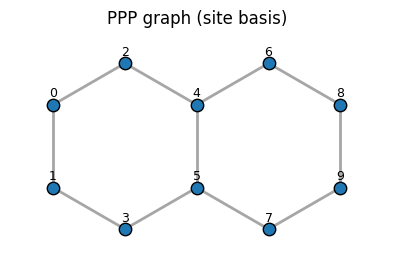

In [2]:
from pyscf.fci import direct_spin1

# PPP model parameters for the base problem-set case: linear n_rings = 2
n_rings = 2

def prepare_case(case_label, n_rings,
                 t0=-2.4, U=11.26, bond_length=1.4, kappa=1.0, run_fci=False):
    """Build the linear PPP model, run RHF/CCSD, and construct the LUCJ circuit."""

    ppp_spin = build_polyacene_ppp(
        n_rings=n_rings,
        t0=t0,
        U=U,
        bond_length=bond_length,
        kappa=kappa,
    )
    hcore_site, eri_site, energy_constant = spinorb_ppp_to_spatial(ppp_spin, U=U)
    num_orbitals = hcore_site.shape[0]
    nelec = (num_orbitals // 2, num_orbitals // 2)

    return {
        "case": case_label,
        "n_rings": n_rings,
        "ppp_spin": ppp_spin,
        "hcore_site": hcore_site,
        "eri_site": eri_site,
        "energy_constant": energy_constant,
        "num_orbitals": num_orbitals,
        "nelec": nelec,
    }

ppp_n2 = prepare_case("n_ring=2", n_rings=2)

print(f"Polyacene rings: {n_rings}")
print(f"Spatial orbitals: {ppp_n2["num_orbitals"]}")
print(f"Spin orbitals / qubits: {2 * ppp_n2["num_orbitals"]}")
print(f"Electrons (alpha, beta): {ppp_n2["nelec"]}")
print(f"Constant intersite Coulomb shift: {ppp_n2["energy_constant"]:.6f} eV")
plot_coordinate(ppp_n2["ppp_spin"])


### Run RHF and CCSD calculation


Next we run RHF/CCSD. The custom driver internally constructs an RHF reference from the supplied `hcore` and `eri` in the site basis, then solves CCSD on top of that reference. This gives us:

- the RHF energy,
- the CCSD energy,
- the CCSD amplitudes `t1` and `t2`, **(will be required for LUCJ ansatz initialization in the main problem)**
- the RHF orbital coefficient matrix `C`.

We then use `C` to rotate the Hamiltonian into the RHF orbital basis. Since the rotation is unitary, the exact Hamiltonian is unchanged; only its representation changes.


In [3]:
def classical_preprocessing(ppp_case, run_fci=False):
    hcore_site, eri_site = ppp_case["hcore_site"], ppp_case["eri_site"]
    nelec, num_orbitals, energy_constant = ppp_case["nelec"], ppp_case["num_orbitals"], ppp_case["energy_constant"]

    ccsd_result = run_ccsd_from_hg(
        h=hcore_site,
        g=eri_site,
        nelec=sum(nelec),
        ecore=energy_constant,
        g_format="chemist",
        verbose=4, # adjust here if you don't want to see the detailed CCSD output.
    )
    hf_energy = ccsd_result["e_hf"]
    ccsd_energy = ccsd_result["e_tot"]
    t1 = ccsd_result["t1"]
    t2 = ccsd_result["t2"]
    mo_coeff = np.asarray(ccsd_result["mf"].mo_coeff, dtype=float)

    hcore_rhf, eri_rhf = transform_integrals_to_mo(
        hcore_site, eri_site, mo_coeff
    )

    if run_fci:
        # Compute the FCI energy in the original site basis for reference
        fci_energy, _ = direct_spin1.kernel(
            hcore_site,
            eri_site,
            num_orbitals,
            nelec,
            ecore=energy_constant,
        )
    else:
        fci_energy = None

    ppp_case["hf_energy"] = hf_energy
    ppp_case["ccsd_energy"] = ccsd_energy
    ppp_case["fci_energy"] = fci_energy
    ppp_case["mo_coeff"] = mo_coeff
    ppp_case["t1"] = t1
    ppp_case["t2"] = t2
    ppp_case["hcore_rhf"] = hcore_rhf
    ppp_case["eri_rhf"] = eri_rhf


classical_preprocessing(ppp_n2, run_fci=True)

print("\n=== RHF/CCSD Results ===")
print(f"RHF energy                     : {ppp_n2["hf_energy"]:.6f} eV")
print(f"CCSD energy                    : {ppp_n2["ccsd_energy"]:.6f} eV")
print(f"FCI energy                     : {ppp_n2["fci_energy"]:.6f} eV")
print(f"t1 shape                       : {ppp_n2["t1"].shape}")
print(f"t2 shape                       : {ppp_n2["t2"].shape}")
print(f"MO coefficient matrix shape    : {ppp_n2["mo_coeff"].shape}")
print(f"||h_site||_F                   : {np.linalg.norm(ppp_n2["hcore_site"]):.6f}")
print(f"||h_rhf||_F                    : {np.linalg.norm(ppp_n2["hcore_rhf"]):.6f}")  # should be the same as h_site due to unitary transformation




******** <class 'pyscf.scf.hf.RHF'> ********
method = RHF
initial guess = 1e
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 200
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmplv5t4y3f
max_memory 4000 MB (current use 190 MB)
Set gradient conv threshold to 3.16228e-05
Initial guess from hcore.
  HOMO = -47.123984160996  LUMO = -45.3269335312375
init E= -8.53661462566137
  HOMO = 3.69137807826927  LUMO = 10.9065137446661
cycle= 1 E= -22.4432958646171  delta_E= -13.9  |g|= 1.88  |ddm|= 2.11
  HOMO = 1.25819466339118  LUMO = 10.1867541909096
cycle= 2 E= -22.5933252317874  delta_E= -0.15  |g|= 0.643  |ddm|= 0.171
  HOMO = 1.17118329146347  LUMO = 10.0647066676206
cycle= 3 E= -22.6148498773611  delta_E= -0.0215  |g|= 0.067  |ddm|= 0.0882
  HOMO = 1.19031802895938  LUMO = 10.0720921231352
cycle= 4 E= -22.6151390087828

Overwritten attributes  get_ovlp get_hcore  of <class 'pyscf.scf.hf.RHF'>


  HOMO = 1.19021506542553  LUMO = 10.0693963714762
cycle= 5 E= -22.615154971781  delta_E= -1.6e-05  |g|= 0.00438  |ddm|= 0.00258
  HOMO = 1.19138229127827  LUMO = 10.0687046147831
cycle= 6 E= -22.6151567618609  delta_E= -1.79e-06  |g|= 0.00038  |ddm|= 0.00113
  HOMO = 1.19130331214563  LUMO = 10.0686864670292
cycle= 7 E= -22.6151567694507  delta_E= -7.59e-09  |g|= 0.000123  |ddm|= 7.91e-05
  HOMO = 1.19132315514523  LUMO = 10.0686763869119
cycle= 8 E= -22.615156770196  delta_E= -7.45e-10  |g|= 1.37e-05  |ddm|= 1.59e-05
  HOMO = 1.19132718742312  LUMO = 10.0686753660108
Extra cycle  E= -22.6151567702049  delta_E= -8.9e-12  |g|= 3.22e-06  |ddm|= 1.55e-06
converged SCF energy = -22.6151567702049
E(CCSD) = -23.97155730201116  E_corr = -1.356400531806293

=== RHF/CCSD Results ===
RHF energy                     : -22.615157 eV
CCSD energy                    : -23.971557 eV
FCI energy                     : -24.008143 eV
t1 shape                       : (5, 5)
t2 shape                       : 

## Problems

Now, based on the tutorial and references, solve and discuss the following problems by completing the code blocks.

### Problem 1. Build an LUCJ ansatz circuit from the CCSD amplitudes

**Goal.** Construct a **local unitary cluster Jastrow (LUCJ)** circuit initialized from the CCSD amplitudes obtained above.

**What you should do**

1. Use the RHF/CCSD amplitudes `t1` and `t2` computed in the base setup.
2. Use the **spin-balanced** LUCJ operator, because the reference state is closed shell.
3. Choose a hardware-friendly interaction pattern. In this reference solution, we use a heavy-hex-inspired sparse pattern:
   - nearest-neighbor pairs for same-spin interactions,
   - every fourth orbital for opposite-spin interactions.
4. Prepare the Hartree-Fock state in Jordan-Wigner ordering.
5. Append the LUCJ operator and add measurements.
6. Transpile the circuit targeting `ibm_yonsei` or any fake Heron backend such as `FakeFez`.
7. Report a few basic diagnostics such as circuit depth and gate counts.

**Deliverables**

- A quantum circuit acting on `2 * num_orbitals` qubits.
- A short explanation of how the interaction pairs were chosen.
- Circuit depth and two-qubit gate count.


alpha_beta_indices = [(0, 0), (4, 4), (8, 8)]


E0511 21:12:41.809413   94096 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0511 21:12:41.821330   92382 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


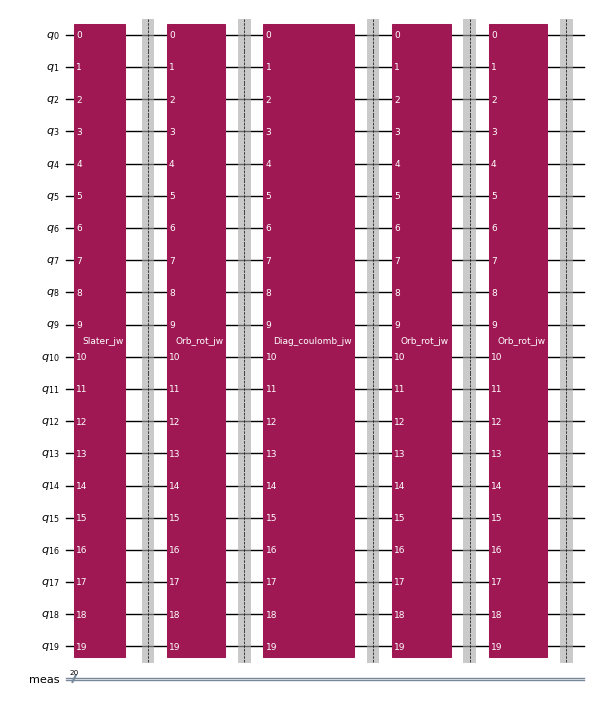

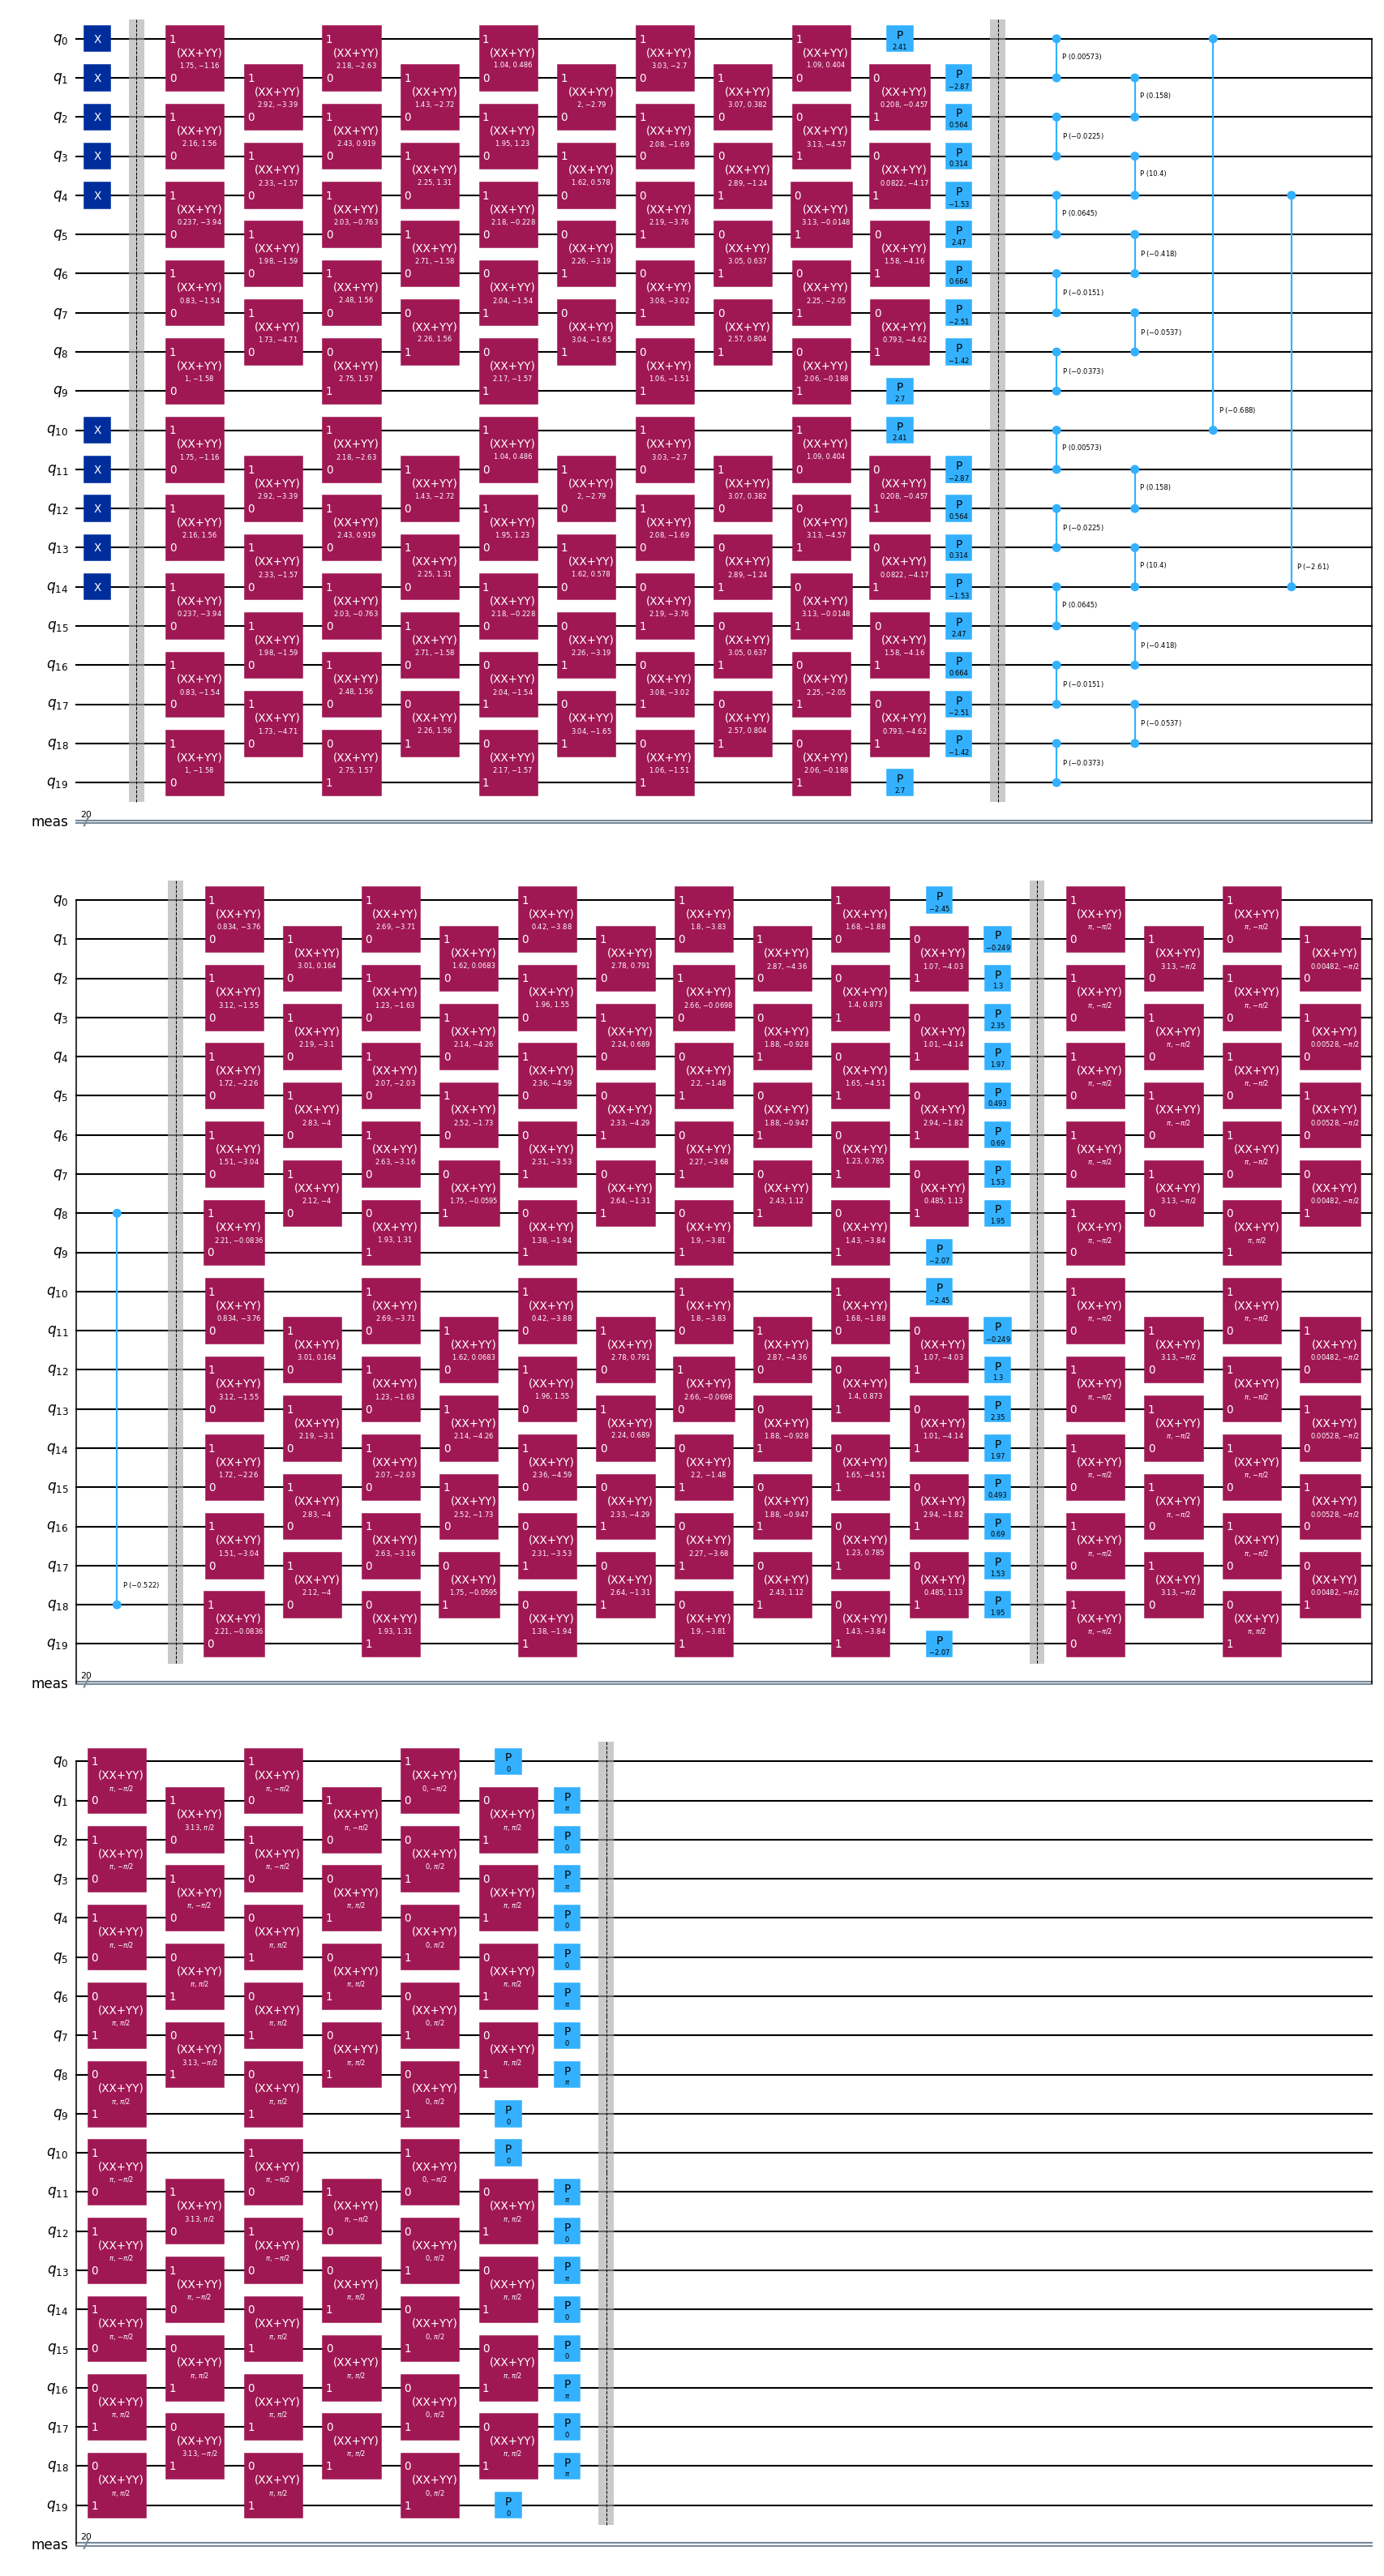

In [4]:
# Reference solution for Problem 1

import ffsim
from qiskit import QuantumCircuit, QuantumRegister
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeNighthawk

backend_fez = FakeFez()
backend_nighthawk = FakeNighthawk()

# TODO: Complete this function
def build_lucj_circuit(ppp_case,
                       n_reps,
                       alpha_alpha_indices,
                       alpha_beta_indices,
                       **kwargs):
    num_orbitals, nelec = ppp_case["num_orbitals"], ppp_case["nelec"]
    t1, t2 = ppp_case["t1"], ppp_case["t2"]

    ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=t2,
        t1=t1,
        n_reps=n_reps,
        interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
        optimize=True,
        options=dict(maxiter=1000),
        **kwargs
    )    
    qubits = QuantumRegister(2 * num_orbitals, name="q")
    lucj_circuit = QuantumCircuit(qubits)
    # Prepare the Hartree-Fock determinant in Jordan-Wigner ordering.
    lucj_circuit.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, nelec), qubits)
    # Apply the spin-balanced UCJ operator.
    lucj_circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
    # Add measurements for bitstring sampling.
    lucj_circuit.measure_all()
    return lucj_circuit


n_reps = 1

# Heavy-hex-inspired sparse interaction pattern.
# The first list is reused for alpha-alpha and beta-beta interactions
# in the spin-balanced UCJ ansatz.
alpha_alpha_indices = [(p, p + 1) for p in range(ppp_n2["num_orbitals"] - 1)]
alpha_beta_indices = None

pass_manager, alpha_beta_indices = ffsim.qiskit.generate_lucj_pass_manager(
    backend=backend_fez,
    norb=ppp_n2["num_orbitals"],
    connectivity="heavy-hex",
    interaction_pairs=(alpha_alpha_indices, None),
    optimization_level=3,
)

print(f"alpha_beta_indices = {alpha_beta_indices}")

lucj_circuit = build_lucj_circuit(ppp_n2, n_reps, alpha_alpha_indices, alpha_beta_indices)

# below code for print
# Decompose the circuit and display (the barriers are just for visual separation of the layers).
lucj_circuit_decomposed = QuantumCircuit(*lucj_circuit.qregs, *lucj_circuit.cregs)
for instr in lucj_circuit.decompose().data:
    if instr.operation.name in ["measure", "barrier"]:
        continue
    lucj_circuit_decomposed.append(instr.operation, instr.qubits, instr.clbits)
    lucj_circuit_decomposed.barrier()
display(lucj_circuit_decomposed.draw("mpl", scale=0.5, fold=-1))

# Further decompose the circuit
display(lucj_circuit_decomposed.decompose().draw("mpl", scale=0.75, fold=33))


In [5]:
lucj_t = pass_manager.run(lucj_circuit)

print("=== LUCJ circuit summary ===")
print(f"n_reps                 : {n_reps}")
print(f"qubits                 : {lucj_t.num_qubits}")
print(f"depth                  : {lucj_t.depth()}")
print(f"size                   : {lucj_t.size()}")
print(f"same-spin pairs        : {len(alpha_alpha_indices)}")
print(f"opposite-spin pairs    : {len(alpha_beta_indices)}")
print(lucj_t.count_ops())

=== LUCJ circuit summary ===
n_reps                 : 1
qubits                 : 156
depth                  : 222
size                   : 2743
same-spin pairs        : 9
opposite-spin pairs    : 3
OrderedDict({'sx': 1201, 'rz': 1166, 'cz': 338, 'measure': 20, 'x': 18, 'barrier': 1})


### Problem 2. Estimate the ground-state energy using SQD and ansatz-generated samples

**Goal.** Replace the uniformly random bitstrings from the tutorial with samples obtained from
the LUCJ ansatz, and then run SQD on those samples.

**What you should do**

1. Generate bitstring samples from the circuit built in Problem 1.
2. Convert the raw counts to the bitstring/probability-array format used by
   `qiskit-addon-sqd`.
3. Run `diagonalize_fermionic_hamiltonian` on the **RHF-basis Hamiltonian**
   (`hcore_rhf`, `eri_rhf`), because the ansatz is defined relative to the RHF reference.
4. Use the Hartree-Fock occupations as the initial occupancy guess.
5. Track the iteration history and compare the final SQD energy against CCSD and, when
   affordable, FCI.

**Deliverables**

- A count dictionary or bitstring array generated from the ansatz circuit.
- An SQD energy estimate.
- A brief comparison to CCSD and optional FCI.


In [6]:
# Reference solution for Problem 2

from functools import partial

from qiskit.primitives import StatevectorSampler
from qiskit_addon_sqd.fermion import SCIResult, diagonalize_fermionic_hamiltonian, solve_sci_batch

# ---------------------------------------------------------------------
# 1) Sample bitstrings from the LUCJ circuit.
# For a local notebook demo, Statevector sampling is simple and robust.
# For hardware execution, replace this part with Sampler / Runtime counts.
# ---------------------------------------------------------------------
shots = 200_000

def sample_bitstring_statevector(lucj_circuit,  # Untranspiled circuit
                                 shots=200_000,
                                 seed=1234):
    rng = np.random.default_rng(seed)
    sampler = StatevectorSampler(seed=rng)
    job = sampler.run([lucj_circuit], shots=shots)
    pub_result = job.result()[0]
    bit_array = pub_result.data.meas
    counts = bit_array.get_counts()
    unique_bitstrings = list(counts.keys())
    return bit_array, unique_bitstrings

bit_array, unique_bitstrings = sample_bitstring_statevector(lucj_circuit, shots, seed=1234)

print("=== Sample summary ===")
print(f"shots                         : {shots}")
print(f"bit_array shape               : {bit_array.array.shape}")
print("number of unique bitstrings:", len(unique_bitstrings))
print(unique_bitstrings[:10])

=== Sample summary ===
shots                         : 200000
bit_array shape               : (200000, 3)
number of unique bitstrings: 1426
['01000110110000011111', '00000111110000011111', '00010111010000011111', '01000101110000011111', '00000111110100011011', '00000111110100010111', '10000011110000011111', '00100101110000011111', '00000111110001011101', '00000111110010010111']


In [7]:
# ---------------------------------------------------------------------
# 2) Run SQD on the RHF-basis Hamiltonian.
# ---------------------------------------------------------------------

def run_sqd_from_hardware_samples(
    ppp_case,
    bit_array,
    num_batches=3,
    samples_per_batch=300,
    max_cycle=200,
    symmetrize_spin = True,
    carryover_threshold = 1e-4,
    energy_tol = 1e-5,
    occupancies_tol = 1e-4,
    max_iterations = 5,
    seed=1234,
    **kwargs
):
    num_orbitals, nelec = ppp_case["num_orbitals"], ppp_case["nelec"]    
    energy_constant = ppp_case["energy_constant"]
    hcore_rhf, eri_rhf = ppp_case["hcore_rhf"], ppp_case["eri_rhf"]

    initial_occupancies = (
        np.array([1] * nelec[0] + [0] * (num_orbitals - nelec[0])),
        np.array([1] * nelec[1] + [0] * (num_orbitals - nelec[1])),
    )

    sci_solver = partial(solve_sci_batch, spin_sq=0.0, max_cycle=max_cycle)

    ansatz_sqd_history = []

    def ansatz_callback(results: list[SCIResult]):
        ansatz_sqd_history.append(results)
        iteration = len(ansatz_sqd_history)
        print(f"RHF-basis SQD | iteration {iteration}")
        for i, result in enumerate(results):
            print(f"    batch {i}")
            print(f"        Energy: {result.energy + energy_constant:.6f} eV")
            print(f"        Subspace dimension: {np.prod(result.sci_state.amplitudes.shape)}")

    ansatz_sqd_result = diagonalize_fermionic_hamiltonian(
        hcore_rhf,
        eri_rhf,
        bit_array,
        samples_per_batch=samples_per_batch,
        norb=num_orbitals,
        nelec=nelec,
        num_batches=num_batches,
        energy_tol=energy_tol,
        occupancies_tol=occupancies_tol,
        max_iterations=max_iterations,
        sci_solver=sci_solver,
        symmetrize_spin=symmetrize_spin,
        initial_occupancies=initial_occupancies,
        carryover_threshold=carryover_threshold,
        callback=ansatz_callback,
        seed=np.random.default_rng(seed),
        **kwargs
    )

    final_sqd_energy = ansatz_sqd_result.energy + energy_constant
    return ansatz_sqd_history, ansatz_sqd_result, final_sqd_energy

sqd_history, sqd_result, final_sqd_energy = run_sqd_from_hardware_samples(ppp_n2, bit_array)

print("\n=== Energy comparison ===")
print(f"HF energy                     : {ppp_n2["hf_energy"]:.6f} eV")
print(f"CCSD energy                   : {ppp_n2["ccsd_energy"]:.6f} eV")
print(f"Final SQD energy              : {final_sqd_energy:.6f} eV")
print(f"FCI energy                    : {ppp_n2["fci_energy"]:.6f} eV")
print(f"SQD - FCI                     : {final_sqd_energy - ppp_n2["fci_energy"]:+.6f} eV")
print(f"SQD - CCSD                    : {final_sqd_energy - ppp_n2["ccsd_energy"]:+.6f} eV")

RHF-basis SQD | iteration 1
    batch 0
        Energy: -23.929824 eV
        Subspace dimension: 7921
    batch 1
        Energy: -23.900363 eV
        Subspace dimension: 6889
    batch 2
        Energy: -23.900433 eV
        Subspace dimension: 6724
RHF-basis SQD | iteration 2
    batch 0
        Energy: -23.946840 eV
        Subspace dimension: 10201
    batch 1
        Energy: -23.958025 eV
        Subspace dimension: 11236
    batch 2
        Energy: -23.963118 eV
        Subspace dimension: 11881
RHF-basis SQD | iteration 3
    batch 0
        Energy: -23.968085 eV
        Subspace dimension: 12996
    batch 1
        Energy: -23.969767 eV
        Subspace dimension: 13689
    batch 2
        Energy: -23.978396 eV
        Subspace dimension: 14884
RHF-basis SQD | iteration 4
    batch 0
        Energy: -23.983779 eV
        Subspace dimension: 16384
    batch 1
        Energy: -23.980566 eV
        Subspace dimension: 15876
    batch 2
        Energy: -23.980743 eV
        Subsp

### Problem 3. Compare the heavy-hex-inspired ansatz with a Nighthawk-style ansatz in the simulator

**Goal.** Investigate how a denser ansatz changes circuit cost and SQD quality.

In Problem 1, the LUCJ ansatz used a sparse interaction pattern motivated by a heavy-hex-like layout:
same-spin interactions were nearest-neighbor along the orbital chain, while opposite-spin interactions were included only at every fourth spatial orbital.
In this problem, compare that sparse ansatz against a **Nighthawk-style ansatz**, in which same-spin interactions remain nearest-neighbor, but opposite-spin interactions are included at **every** spatial orbital.

**What you should do**

1. Reuse the sparse heavy-hex-inspired LUCJ circuit from Problem 1.
2. Build a denser Nighthawk-style ansatz with:
   - nearest-neighbor same-spin pairs (`alpha_alpha_indices`)
   $$
   (p, p+1), \qquad 0 \le p < \texttt{norb} - 1,
   $$
   - and opposite-spin pairs at every spatial orbital (`alpha_beta_indices`)
   $$
   (p, p), \qquad 0 \le p < \texttt{norb}.
   $$
3. Transpile both circuits to the same hardware-like backend and compare:
   - circuit depth,
   - circuit size,
   - the number of same-spin and opposite-spin interaction pairs.
4. Generate simulator samples from both circuits and run SQD on the RHF-basis Hamiltonian.
5. Compare the final SQD energies against CCSD and discuss the tradeoff between expressivity and circuit cost.

**Deliverables**

- A Nighthawk-style LUCJ circuit construction.
- A direct comparison with the sparse heavy-hex-inspired circuit from Problem 1.
- A short discussion of whether the denser Nighthawk-style ansatz seems worthwhile in the simulator.

In [8]:
# Reference solution for Problem 3

import pandas as pd

alpha_alpha = [(p, p + 1) for p in range(ppp_n2["num_orbitals"] - 1)]

# From the previous one
lucj_circuit_fez = lucj_circuit
alpha_beta_fez = alpha_beta_indices
lucj_t_fez = lucj_t
lucj_t_fez = lucj_t
bit_array_fez, unique_bitstrings_fez = bit_array, unique_bitstrings
sqd_history_fez, sqd_result_fez, final_sqd_energy_fez = sqd_history, sqd_result, final_sqd_energy


# Build for nighthawk
pass_manager_nighthawk, alpha_beta_nighthawk = ffsim.qiskit.generate_lucj_pass_manager(
    backend=backend_nighthawk,
    norb=ppp_n2["num_orbitals"],
    connectivity="square",
    interaction_pairs=(alpha_alpha, None),
    optimization_level=3,
)

print(f"Fez alpha-beta indices: {alpha_beta_fez}")
print(f"Nighthawk alpha-beta indices: {alpha_beta_nighthawk}")

lucj_circuit_nighthawk = build_lucj_circuit(ppp_n2, n_reps, alpha_alpha, alpha_beta_nighthawk)

# Transpile
lucj_t_nighthawk = pass_manager_nighthawk.run(lucj_circuit_nighthawk)

# Execute
bit_array_nighthawk, unique_bitstrings_nighthawk = sample_bitstring_statevector(lucj_circuit_nighthawk, shots, seed=1234)

# Postprocess
sqd_history_nighthawk, sqd_result_nighthawk, final_sqd_energy_nighthawk = run_sqd_from_hardware_samples(ppp_n2, bit_array_nighthawk)


Fez alpha-beta indices: [(0, 0), (4, 4), (8, 8)]
Nighthawk alpha-beta indices: [(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9)]
RHF-basis SQD | iteration 1
    batch 0
        Energy: -23.903418 eV
        Subspace dimension: 9025
    batch 1
        Energy: -23.938455 eV
        Subspace dimension: 8281
    batch 2
        Energy: -23.939704 eV
        Subspace dimension: 8836
RHF-basis SQD | iteration 2
    batch 0
        Energy: -23.953240 eV
        Subspace dimension: 12100
    batch 1
        Energy: -23.951737 eV
        Subspace dimension: 11025
    batch 2
        Energy: -23.953112 eV
        Subspace dimension: 11881
RHF-basis SQD | iteration 3
    batch 0
        Energy: -23.963298 eV
        Subspace dimension: 12996
    batch 1
        Energy: -23.960443 eV
        Subspace dimension: 13225
    batch 2
        Energy: -23.964676 eV
        Subspace dimension: 13456
RHF-basis SQD | iteration 4
    batch 0
        Energy: -23.966975 eV
     

In [ ]:
problem3_compare_df = pd.DataFrame(
    [
        {
            "ansatz": "Heron's heavy-hex",
            "depth": lucj_t_fez.depth(),
            "size": lucj_t_fez.size(),
            "qubits": lucj_t_fez.num_qubits,
            "same_spin_pairs": len(alpha_alpha),
            "opposite_spin_pairs": len(alpha_beta_fez),
            "unique_samples": len(unique_bitstrings_fez),
            "sqd_energy": final_sqd_energy_fez,
            "sqd_minus_ccsd": final_sqd_energy_fez - ppp_n2["ccsd_energy"],
        },
        {
            "ansatz": "Nighthawk's square",
            "depth": lucj_t_nighthawk.depth(),
            "size": lucj_t_nighthawk.size(),
            "qubits": lucj_t_nighthawk.num_qubits,
            "same_spin_pairs": len(alpha_alpha),
            "opposite_spin_pairs": len(alpha_beta_nighthawk),
            "unique_samples": len(unique_bitstrings_nighthawk),
            "sqd_energy": final_sqd_energy_nighthawk,
            "sqd_minus_ccsd": final_sqd_energy_nighthawk - ppp_n2["ccsd_energy"],
        },
    ]
)

print("\n=== Problem 3 comparison summary ===")
display(problem3_compare_df)



=== Problem 3 comparison summary ===


,ansatz,depth,size,qubits,same_spin_pairs,opposite_spin_pairs,unique_samples,sqd_energy,sqd_minus_ccsd
0,Heron's heavy-hex,222,2743,156,9,3,"[01000110110000011111, 00000111110000011111, 0...",-23.988019,-0.016461
1,Nighthawk's square,213,2747,120,9,10,"[01000101110000011111, 00000111110000011111, 0...",-23.970911,0.000647


### Problem 4. (Advanced) Scale up to linear `n_rings = 3`, but reserve sampling for a real backend

**Goal.** Integrate the workflow to scale up to the real-backend utility.

In this notebook, use the same **linear polyacene** PPP utility throughout.
In thie problem, prepare the larger `n_rings = 3` case for a real backend.

**What you should do**

1. Build the PPP → RHF/CCSD → LUCJ construction workflow for the `n_rings = 3` case using the same PPP parameter setting, and compute at least:
   - the RHF energy,
   - the CCSD energy,
   - the ansatz circuit size/depth after transpilation to a hardware-like backend.
2. If you have access to a real backend, collect samples for the `n_rings = 3` circuit there and then run SQD on those hardware samples.

**Practical note.** Do not run local `StatevectorSampler` sampling for `n_rings = 3` in this notebook, it takes too much memory and time.


In [11]:
ppp_n3 = prepare_case("n_rings=3", n_rings=3)
classical_preprocessing(ppp_n3, run_fci=False)

# TODO



******** <class 'pyscf.scf.hf.RHF'> ********
method = RHF
initial guess = 1e
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 200
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmp5jni9xy2
max_memory 4000 MB (current use 2481 MB)
Set gradient conv threshold to 3.16228e-05
Initial guess from hcore.
  HOMO = -57.2440223059112  LUMO = -57.1521783230672
init E= 42.7774641778162
  HOMO = 9.11589850929857  LUMO = 9.33602203089068
cycle= 1 E= 18.4882864728584  delta_E= -24.3  |g|= 26.9  |ddm|= 5.89
  HOMO = 2.26923429958584  LUMO = 2.73567257802657
cycle= 2 E= 2.54402093916872  delta_E= -15.9  |g|= 24.6  |ddm|= 4.98
  HOMO = 3.88984990020034  LUMO = 6.64298373753643
cycle= 3 E= -30.44634692203  delta_E=  -33  |g|= 4.66  |ddm|= 2.83
  HOMO = 1.55898303653315  LUMO = 9.78786398291071
cycle= 4 E= -31.6920147116282  delta_E= 